In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# =========================
# ✅ Mac 한글 폰트 설정
# =========================
plt.rcParams["font.family"] = "AppleGothic"      # 맥 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 깨짐 방지


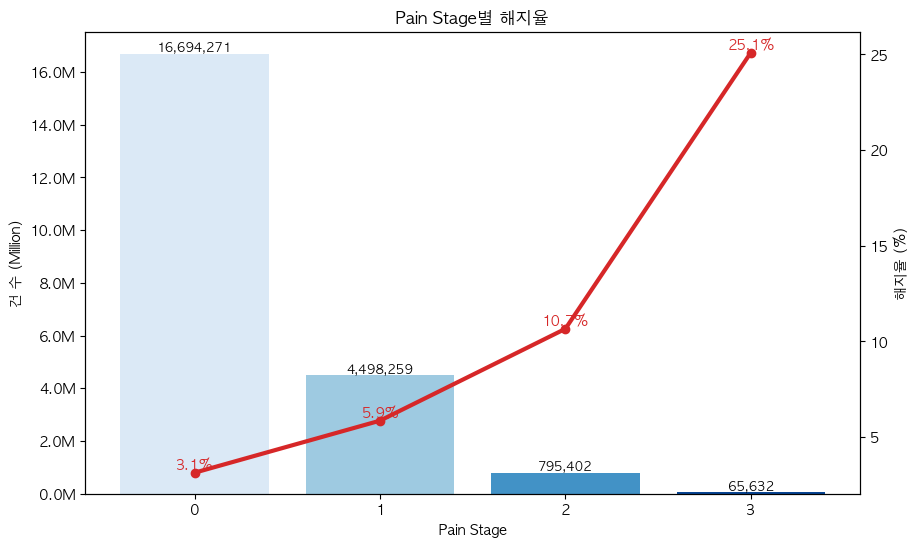

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

# 데이터 생성
data = pd.DataFrame({
    "pain_stage": [0, 1, 2, 3],
    "count": [16694271, 4498259, 795402, 65632],
    "churn_rate": [3.14,5.86,10.66,25.09 ]
})

fig, ax1 = plt.subplots(figsize=(10, 6))

# -----------------------------
# 막대그래프 (건 수)
# -----------------------------
bar_colors = ['#dbe9f6', '#9ecae1', '#4292c6', '#084594']
bars = ax1.bar(data["pain_stage"], data["count"], color=bar_colors)

ax1.set_xlabel("Pain Stage")
ax1.set_ylabel("건 수 (Million)")
ax1.set_xticks(data["pain_stage"])

# 축은 백만 단위로
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1_000_000:.1f}M'))

# 막대 위 실제 숫자 표시
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# -----------------------------
# 선그래프 (해지율)
# -----------------------------
ax2 = ax1.twinx()
line = ax2.plot(
    data["pain_stage"],
    data["churn_rate"],
    marker='o',
    linewidth=3,
    color='#d62728'
)

ax2.set_ylabel("해지율 (%)")

# ✅ 해지율 점 위에 % 표시
for x, y in zip(data["pain_stage"], data["churn_rate"]):
    ax2.text(
        x,
        y,
        f'{y:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        color='#d62728'
    )

plt.title("Pain Stage별 해지율")

plt.show()


Index(['months_before_churn', 'n', 'stb_res_rate', 'voc_total_rate',
       'voc_stop_rate'],
      dtype='object')
   months_before_churn        n  stb_res_rate  voc_total_rate  voc_stop_rate
0                    0  1309642      0.198195        0.232258       0.061987
1                    1  1118820      0.187058        0.205828       0.036352
2                    2   944619      0.178607        0.203931       0.033985
3                    3   784519      0.171460        0.204922       0.033241
4                    4   637464      0.165129        0.208496       0.033268


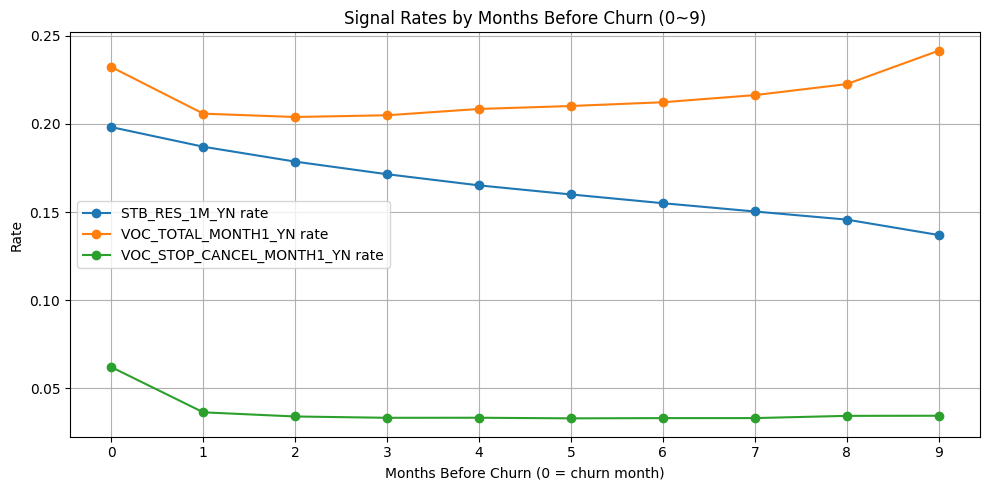

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) CSV 로드
# =========================
csv_path = "/Users/bagjimin/Desktop/LG_HelloVision/PROJECT/dataset/processed/signal_rates_lookback_0_9.csv"
df = pd.read_csv(csv_path)

# 컬럼 확인(혹시 이름 다르면 여기서 바로 잡기)
print(df.columns)
print(df.head())

# 정렬(안전장치)
df = df.sort_values("months_before_churn")

# =========================
# 2) 3개 신호율 겹쳐 그리기 (Line Chart)
# =========================
plt.figure(figsize=(10, 5))

plt.plot(df["months_before_churn"], df["stb_res_rate"], marker="o", label="STB_RES_1M_YN rate")
plt.plot(df["months_before_churn"], df["voc_total_rate"], marker="o", label="VOC_TOTAL_MONTH1_YN rate")
plt.plot(df["months_before_churn"], df["voc_stop_rate"], marker="o", label="VOC_STOP_CANCEL_MONTH1_YN rate")

plt.xlabel("Months Before Churn (0 = churn month)")
plt.ylabel("Rate")
plt.title("Signal Rates by Months Before Churn (0~9)")
plt.xticks(df["months_before_churn"])  # 0~9 눈금 고정
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 3) (선택) CSV로 다시 저장 (정리본)
# =========================
# out_path = "/Users/bagjimin/Desktop/LG_HelloVision/PROJECT/dataset/processed/signal_rates_lookback_0_9_clean.csv"
# df.to_csv(out_path, index=False)
# print("Saved:", out_path)
